In [ ]:
# EU Road Freight Transport Analysis
## Post-COVID Recovery and Country-Level Performance (2019–2024)

**Dataset:** Eurostat Road Freight Transport — `road_go_ta_tott`  
**Source:** https://ec.europa.eu/eurostat/databrowser/view/road_go_ta_tott  
**Author:** Nate Slater

### Analytical Questions
1. How has total EU road freight volume trended since the COVID-19 disruption?
2. Which countries are driving growth or decline in 2023-2024?
3. How does the national vs international transport split vary by country?
4. Which countries have recovered to pre-COVID levels and which have not?

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# Load the dataset with low_memory=False to handle mixed types
df = pd.read_csv(r'C:\dev\portfolio\project-3-eu-road-tpt\dataset\road_go_ta_tott_linear.csv', low_memory=False)

# Basic shape
print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns)}')
print(f'\nColumn names:')
print(df.columns.tolist())
print(f'\nFirst few rows:')
df.head(10)

Rows: 73,212
Columns: 11

Column names:
['DATAFLOW', 'LAST UPDATE', 'freq', 'tra_type', 'tra_oper', 'unit', 'geo', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS']

First few rows:


,DATAFLOW,LAST UPDATE,freq,tra_type,tra_oper,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:ROAD_GO_TA_TOTT(1.0),17/02/26 23:00:00,Annual,Hire or reward,Empty - international transport - total,Million tonne-kilometre (TKM),Austria,1999,NaN,m,NaN
1,ESTAT:ROAD_GO_TA_TOTT(1.0),17/02/26 23:00:00,Annual,Hire or reward,Empty - international transport - total,Million tonne-kilometre (TKM),Austria,2000,NaN,m,NaN
2,ESTAT:ROAD_GO_TA_TOTT(1.0),17/02/26 23:00:00,Annual,Hire or reward,Empty - international transport - total,Million tonne-kilometre (TKM),Austria,2001,NaN,m,NaN
3,ESTAT:ROAD_GO_TA_TOTT(1.0),17/02/26 23:00:00,Annual,Hire or reward,Empty - international transport - total,Million tonne-kilometre (TKM),Austria,2002,NaN,m,NaN
4,ESTAT:ROAD_GO_TA_TOTT(1.0),17/02/26 23:00:00,Annual,Hire or reward,Empty - international transport - total,Million tonne-kilometre (TKM),Austria,2003,NaN,m,NaN
5,ESTAT:ROAD_GO_TA_TOTT(1.0),17/02/26 23:00:00,Annual,Hire or reward,Empty - international transport - total,Million tonne-kilometre (TKM),Austria,2004,NaN,m,NaN
6,ESTAT:ROAD_GO_TA_TOTT(1.0),17/02/26 23:00:00,Annual,Hire or reward,Empty - international transport - total,Million tonne-kilometre (TKM),Austria,2005,NaN,m,NaN
7,ESTAT:ROAD_GO_TA_TOTT(1.0),17/02/26 23:00:00,Annual,Hire or reward,Empty - international transport - total,Million tonne-kilometre (TKM),Austria,2006,NaN,m,NaN
8,ESTAT:ROAD_GO_TA_TOTT(1.0),17/02/26 23:00:00,Annual,Hire or reward,Empty - international transport - total,Million tonne-kilometre (TKM),Austria,2007,NaN,m,NaN
9,ESTAT:ROAD_GO_TA_TOTT(1.0),17/02/26 23:00:00,Annual,Hire or reward,Empty - international transport - total,Million tonne-kilometre (TKM),Austria,2008,NaN,m,NaN


In [3]:
# Understand the key dimensions
print('Transport types (tra_type):')
print(df['tra_type'].unique())

print('\nTransport operations (tra_oper):')
print(df['tra_oper'].unique())

print('\nUnits (unit):')
print(df['unit'].unique())

print('\nYear range:')
print(f"{df['TIME_PERIOD'].min()} to {df['TIME_PERIOD'].max()}")

print('\nCountries (geo):')
print(sorted(df['geo'].unique()))

print('\nNull values in OBS_VALUE:')
print(f"{df['OBS_VALUE'].isna().sum():,} of {len(df):,} rows ({100*df['OBS_VALUE'].isna().mean():.1f}%)")

Transport types (tra_type):
['Hire or reward' 'Not specified' 'Own account' 'Total']

Transport operations (tra_oper):
['Empty - international transport - total' 'Empty - total transport'
 'Empty - national transport' 'Loaded - international transport - total'
 'Loaded - international - cabotage'
 'Loaded - international - cross-trade'
 'Loaded - international - goods loaded in reporting country'
 'Loaded - international - goods unloaded in reporting country'
 'Loaded - national transport' 'Loaded - total transport'
 'Total - total transport']

Units (unit):
['Million tonne-kilometre (TKM)' 'Million vehicle-kilometres (VKM)'
 'Thousand tonnes']

Year range:
1999 to 2024

Countries (geo):
['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'European Union - 15 countries (1995-2004)', 'European Union - 25 countries (2004-2006)', 'European Union - 27 countries (2007-2013)', 'European Union - 27 countries (from 2020)', 'European Union - 28 countries (20

In [10]:
# Filter to the data we need
df_filtered = df[
    (df['tra_type'] == 'Total') &
    (df['tra_oper'] == 'Total - total transport') &
    (df['unit'] == 'Million tonne-kilometre (TKM)') &
    (df['TIME_PERIOD'] >= 2019)
].copy()

# Separate country-level from EU aggregates
eu_aggregates = [
    'European Union - 15 countries (1995-2004)',
    'European Union - 25 countries (2004-2006)',
    'European Union - 27 countries (2007-2013)',
    'European Union - 27 countries (from 2020)',
    'European Union - 28 countries (2013-2020)'
]

df_countries = df_filtered[~df_filtered['geo'].isin(eu_aggregates)].copy()
df_eu = df_filtered[df_filtered['geo'] == 'European Union - 27 countries (from 2020)'].copy()

# Drop nulls
df_countries = df_countries.dropna(subset=['OBS_VALUE'])
df_eu = df_eu.dropna(subset=['OBS_VALUE'])

# Clean up columns
df_countries = df_countries[['geo', 'TIME_PERIOD', 'OBS_VALUE']].rename(columns={
    'geo': 'country',
    'TIME_PERIOD': 'year',
    'OBS_VALUE': 'tkm_millions'
})

df_eu = df_eu[['geo', 'TIME_PERIOD', 'OBS_VALUE']].rename(columns={
    'geo': 'group',
    'TIME_PERIOD': 'year',
    'OBS_VALUE': 'tkm_millions'
})

print(f'Country-level rows: {len(df_countries):,}')
print(f'EU aggregate rows: {len(df_eu):,}')
print(f'\nCountries included: {sorted(df_countries["country"].unique())}')
print(f'\nYears: {sorted(df_countries["year"].unique())}')
df_countries.head(10)

# Add this to Cell 5 after existing code
df_eu_longrun = df[
    (df['tra_type'] == 'Total') &
    (df['tra_oper'] == 'Total - total transport') &
    (df['unit'] == 'Million tonne-kilometre (TKM)') &
    (df['TIME_PERIOD'] >= 2015) &
    (df['geo'] == 'European Union - 27 countries (from 2020)')
].copy()

df_eu_longrun = df_eu_longrun.dropna(subset=['OBS_VALUE'])
df_eu_longrun = df_eu_longrun[['TIME_PERIOD', 'OBS_VALUE']].rename(columns={
    'TIME_PERIOD': 'year',
    'OBS_VALUE': 'tkm_millions'
})

print('\nLong-run EU data:')
print(df_eu_longrun.to_string(index=False))

Country-level rows: 176
EU aggregate rows: 6

Countries included: ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'United Kingdom']

Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Long-run EU data:
 year  tkm_millions
 2015  1,614,870.00
 2016  1,675,444.00
 2017  1,758,318.00
 2018  1,761,866.00
 2019  1,813,524.00
 2020  1,799,634.00
 2021  1,920,510.00
 2022  1,918,566.00
 2023  1,857,006.00
 2024  1,868,775.00


## Data Preparation Notes

The raw dataset contains 73,212 rows spanning multiple transport types, operations, units, and years from 1999–2024.

For this analysis we filtered to:
- **Transport type:** Total (all operators)
- **Transport operation:** Total — all loaded and empty movements
- **Unit:** Million tonne-kilometres (TKM) — the standard measure of freight performance
- **Years:** 2019–2024 — capturing pre-COVID baseline, disruption, recovery, and current state
- **Geography:** Country-level only, excluding EU aggregate rows

This leaves **176 observations** across **31 countries** and **6 years**.

Note: Liechtenstein and Cyprus were excluded due to missing data across the full period.

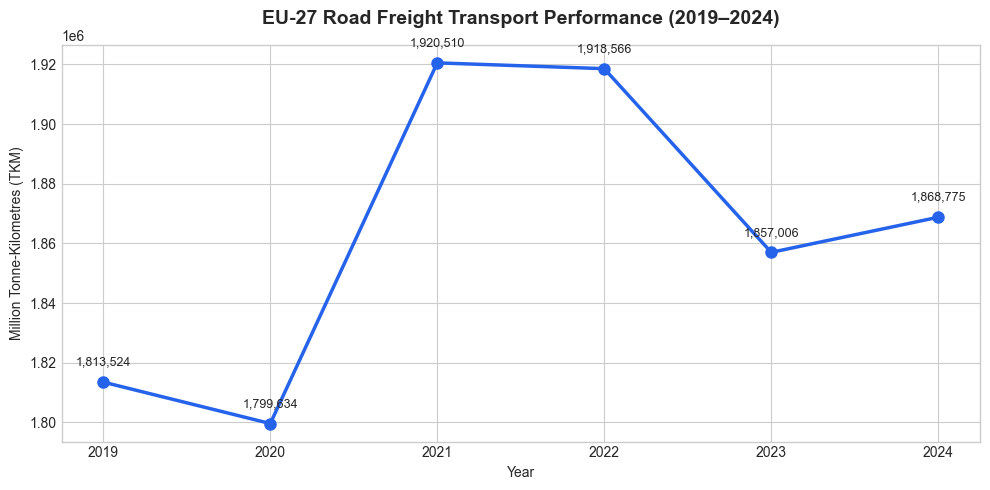


EU-27 Data:
 year  tkm_millions
 2019  1,813,524.00
 2020  1,799,634.00
 2021  1,920,510.00
 2022  1,918,566.00
 2023  1,857,006.00
 2024  1,868,775.00


In [5]:
# EU-level trend 2019-2024
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_eu['year'], df_eu['tkm_millions'], 
        marker='o', linewidth=2.5, color='#2563eb', markersize=8)

# Annotate each point
for _, row in df_eu.iterrows():
    ax.annotate(f"{row['tkm_millions']:,.0f}", 
                xy=(row['year'], row['tkm_millions']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9)

ax.set_title('EU-27 Road Freight Transport Performance (2019–2024)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Million Tonne-Kilometres (TKM)')
ax.set_xticks(df_eu['year'])

plt.tight_layout()
plt.savefig(r'C:\dev\portfolio\project-3-eu-road-tpt\charts\chart1_eu_trend.png', dpi=150)
plt.show()

print('\nEU-27 Data:')
print(df_eu[['year', 'tkm_millions']].to_string(index=False))

## Finding 1: EU Road Freight Has Not Fully Recovered to 2021-2022 Peak

Total EU-27 road freight performance shows a clear arc across the period:

- The COVID-19 disruption in 2020 caused a surprisingly modest decline of just 0.8%
- A strong recovery in 2021 pushed volumes **6% above pre-COVID levels**
- 2022 held near the peak, but 2023 saw a more significant contraction of **3.2%**
- 2024 shows early signs of stabilisation with a marginal 0.6% increase

The 2023 contraction — driven by macroeconomic headwinds, energy costs, and softening demand — 
proved more damaging to freight volumes than the pandemic itself.

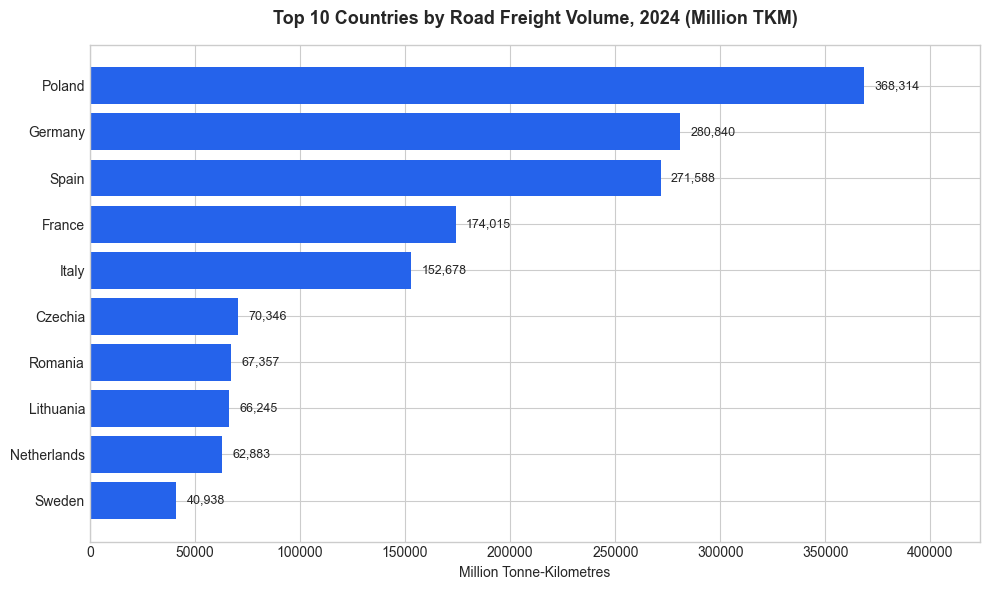


Top 10 countries 2024:
    country  tkm_millions
     Poland    368,314.00
    Germany    280,840.00
      Spain    271,588.00
     France    174,015.00
      Italy    152,678.00
    Czechia     70,346.00
    Romania     67,357.00
  Lithuania     66,245.00
Netherlands     62,883.00
     Sweden     40,938.00


In [6]:
# Top 10 countries by 2024 TKM
df_2024 = df_countries[df_countries['year'] == 2024].sort_values('tkm_millions', ascending=True)
top10_2024 = df_2024.nlargest(10, 'tkm_millions').sort_values('tkm_millions')

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top10_2024['country'], top10_2024['tkm_millions'], color='#2563eb')

# Add value labels
for bar, val in zip(bars, top10_2024['tkm_millions']):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9)

ax.set_title('Top 10 Countries by Road Freight Volume, 2024 (Million TKM)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Million Tonne-Kilometres')
ax.set_xlim(0, top10_2024['tkm_millions'].max() * 1.15)

plt.tight_layout()
plt.savefig(r'C:\dev\portfolio\project-3-eu-road-tpt\charts\chart2_top10_2024.png', dpi=150)
plt.show()

print('\nTop 10 countries 2024:')
print(top10_2024[['country', 'tkm_millions']].sort_values('tkm_millions', ascending=False).to_string(index=False))

## Finding 2: Poland, Germany and Spain Dominate EU Road Freight

In 2024, the top 3 countries account for nearly half of the top 10 total volume:

- **Poland (368,314M TKM)** is the single largest road freight nation in the EU — 
  reflecting its geographic position as the primary east-west transit corridor and 
  its highly competitive trucking industry
- **Germany (280,840M TKM)** — Europe's largest economy and central freight hub
- **Spain (271,588M TKM)** — significant domestic market and Iberian peninsula gateway

Notable: Lithuania (population ~2.8M) ranks 8th — reflecting the outsized role of 
Baltic states in international freight operations relative to their economic size.

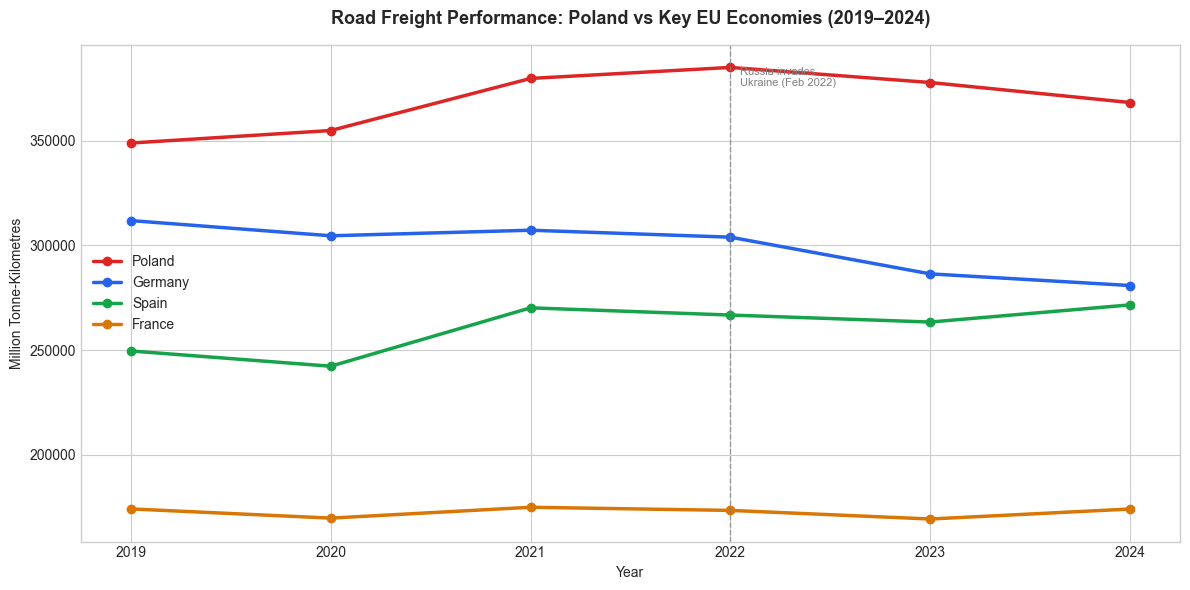


Year-by-year comparison (Million TKM):
country     France    Germany     Poland      Spain
year                                               
2019    174,061.00 311,875.00 348,952.00 249,559.00
2020    169,663.00 304,613.00 354,927.00 242,268.00
2021    174,853.00 307,272.00 379,820.00 270,176.00
2022    173,353.00 303,948.00 385,089.00 266,724.00
2023    169,240.00 286,408.00 377,873.00 263,382.00
2024    174,015.00 280,840.00 368,314.00 271,588.00


In [16]:
# Poland vs Germany vs EU average trend
countries_of_interest = ['Poland', 'Germany', 'Spain', 'France']

df_compare = df_countries[df_countries['country'].isin(countries_of_interest)].copy()

# Also calculate EU average across all countries per year
df_eu_avg = df_countries.groupby('year')['tkm_millions'].sum().reset_index()
df_eu_avg['country'] = 'EU-27 Total'
df_eu_avg.columns = ['year', 'tkm_millions', 'country']

fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    'Poland': '#dc2626',
    'Germany': '#2563eb', 
    'Spain': '#16a34a',
    'France': '#d97706'
}

for country in countries_of_interest:
    data = df_compare[df_compare['country'] == country]
    ax.plot(data['year'], data['tkm_millions'],
            marker='o', linewidth=2.5, label=country,
            color=colors[country])

# Mark the Ukraine invasion
ax.axvline(x=2022, color='grey', linewidth=1, linestyle='--', alpha=0.7)
ax.text(2022.05, ax.get_ylim()[1] * 0.95, 
        'Russia invades\nUkraine (Feb 2022)', 
        fontsize=8, color='grey')

ax.set_title('Road Freight Performance: Poland vs Key EU Economies (2019–2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Million Tonne-Kilometres')
ax.set_xticks(df_compare['year'].unique())
ax.legend()

plt.tight_layout()
plt.savefig(r'C:\dev\portfolio\project-3-eu-road-tpt\charts\chart4_poland_vs_peers.png', dpi=150)
plt.show()

# Print the numbers
print('\nYear-by-year comparison (Million TKM):')
pivot = df_compare.pivot(index='year', columns='country', values='tkm_millions')
print(pivot.to_string())

# Extended dataset from 2010 for Czechia analysis
df_countries_full = df[
    (df['tra_type'] == 'Total') &
    (df['tra_oper'] == 'Total - total transport') &
    (df['unit'] == 'Million tonne-kilometre (TKM)') &
    (df['TIME_PERIOD'] >= 2010) &
    (~df['geo'].isin(eu_aggregates))
].copy()

df_countries_full = df_countries_full.dropna(subset=['OBS_VALUE'])
df_countries_full = df_countries_full[['geo', 'TIME_PERIOD', 'OBS_VALUE']].rename(columns={
    'geo': 'country',
    'TIME_PERIOD': 'year',
    'OBS_VALUE': 'tkm_millions'
})

## Finding 3: Poland's Dominance Is Structural, Not Purely Geopolitical

A natural hypothesis is that Poland's large freight volume relative to Germany 
reflects Ukraine's post-2022 reliance on Polish logistics corridors following 
the Russian invasion. The data tells a more nuanced story.

| Year | Poland | Germany | Difference |
|------|--------|---------|------------|
| 2019 | 348,952 | 311,875 | +37,077 |
| 2020 | 354,927 | 304,613 | +50,314 |
| 2021 | 379,820 | 307,272 | +72,548 |
| 2022 | 385,089 | 303,948 | +81,141 |
| 2023 | 377,873 | 286,408 | +91,465 |
| 2024 | 368,314 | 280,840 | +87,474 |

Key observations:
- Poland already exceeded Germany in 2019 — pre-invasion
- The post-2022 gap widened, consistent with Ukraine corridor effects
- However Germany's decline reflects its own structural problems: energy costs, weak manufacturing, and industrial contraction
- Poland's resilience in 2023 (vs peers) is consistent with Ukraine trade providing a partial buffer against the broader EU freight contraction

**Conclusion:** Poland's dominance is driven primarily by structural competitive 
advantages: geographic position, lower labour costs, and fleet scale. 
The Ukraine conflict likely contributed to widening the gap post-2022, 
but is not the primary explanation.

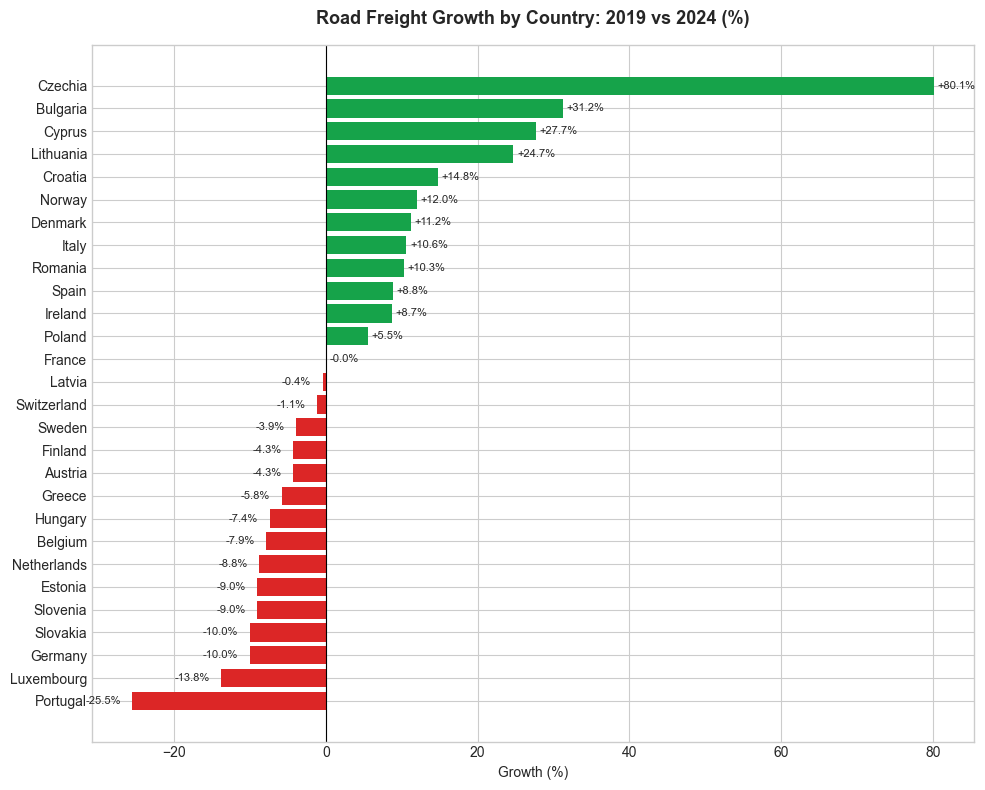


Growth rates 2019-2024:
    country   tkm_2019   tkm_2024  growth_pct
   Portugal  31,014.00  23,120.00      -25.50
 Luxembourg   7,381.00   6,364.00      -13.80
    Germany 311,875.00 280,840.00      -10.00
   Slovakia  33,941.00  30,562.00      -10.00
   Slovenia  24,011.00  21,857.00       -9.00
    Estonia   4,794.00   4,363.00       -9.00
Netherlands  68,923.00  62,883.00       -8.80
    Belgium  34,830.00  32,090.00       -7.90
    Hungary  36,951.00  34,231.00       -7.40
     Greece  21,844.00  20,574.00       -5.80
    Austria  26,444.00  25,315.00       -4.30
    Finland  28,848.00  27,603.00       -4.30
     Sweden  42,604.00  40,938.00       -3.90
Switzerland  12,399.00  12,268.00       -1.10
     Latvia  14,965.00  14,906.00       -0.40
     France 174,061.00 174,015.00       -0.00
     Poland 348,952.00 368,314.00        5.50
    Ireland  12,444.00  13,529.00        8.70
      Spain 249,559.00 271,588.00        8.80
    Romania  61,041.00  67,357.00       10.30
      Ita

In [7]:
# Calculate growth from 2019 to 2024 by country
df_2019 = df_countries[df_countries['year'] == 2019][['country', 'tkm_millions']].rename(
    columns={'tkm_millions': 'tkm_2019'})
df_2024 = df_countries[df_countries['year'] == 2024][['country', 'tkm_millions']].rename(
    columns={'tkm_millions': 'tkm_2024'})

df_growth = df_2019.merge(df_2024, on='country')
df_growth['growth_pct'] = ((df_growth['tkm_2024'] - df_growth['tkm_2019']) / 
                            df_growth['tkm_2019'] * 100).round(1)

df_growth = df_growth.sort_values('growth_pct', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#dc2626' if x < 0 else '#16a34a' for x in df_growth['growth_pct']]
bars = ax.barh(df_growth['country'], df_growth['growth_pct'], color=colors)

# Add value labels
for bar, val in zip(bars, df_growth['growth_pct']):
    offset = -1.5 if val < 0 else 0.5
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', fontsize=8,
            ha='right' if val < 0 else 'left')

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Road Freight Growth by Country: 2019 vs 2024 (%)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Growth (%)')

plt.tight_layout()
plt.savefig(r'C:\dev\portfolio\project-3-eu-road-tpt\charts\chart3_growth_rates.png', dpi=150)
plt.show()

print('\nGrowth rates 2019-2024:')
print(df_growth[['country', 'tkm_2019', 'tkm_2024', 'growth_pct']].to_string(index=False))

## Finding 4: A Clear East-West Divide in Road Freight Performance (2019–2024)

The growth rate analysis reveals a structural geographic pattern across European 
road freight:

**Contracting (Western Europe):**
- Portugal (-25.5%), Luxembourg (-13.8%), Germany (-10.0%), Slovakia (-10.0%)
- 15 of 28 countries recorded net declines over the period
- Reflects energy price shocks, industrial contraction, and weak demand

**Growing (Eastern/Central Europe):**
- Czechia (+80.1%)*, Lithuania (+24.7%), Bulgaria (+31.2%), Croatia (+14.8%)
- Eastern corridor countries are gaining share as supply chains restructure
- Lower operating costs and central positioning increasingly attractive

**The pattern:**
The divide broadly follows a west-east axis, consistent with:
1. Lower labour and fuel costs in eastern member states
2. Supply chain nearshoring shifting activity eastward post-COVID
3. Growing intra-EU trade flows through central European corridors

*Note: Czechia's +80.1% growth is a statistical outlier warranting further 
investigation, possible methodological changes in national reporting may 
partially explain this figure.

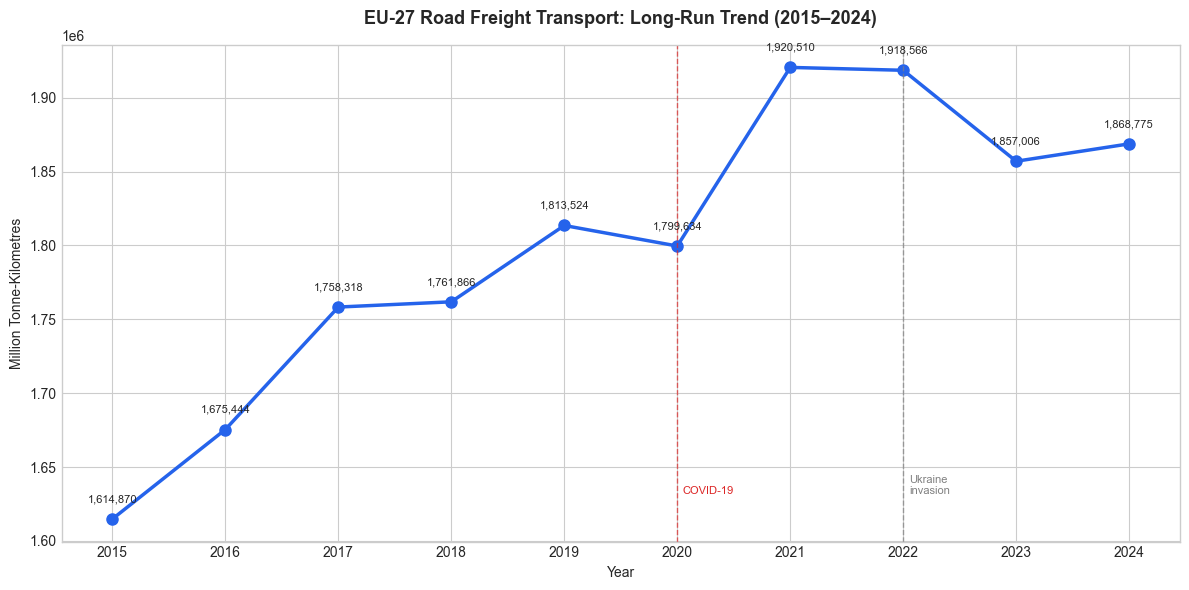

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_eu_longrun['year'], df_eu_longrun['tkm_millions'],
        marker='o', linewidth=2.5, color='#2563eb', markersize=8)

# Annotate each point
for _, row in df_eu_longrun.iterrows():
    ax.annotate(f"{row['tkm_millions']:,.0f}",
                xy=(row['year'], row['tkm_millions']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=8)

# Mark key events
ax.axvline(x=2020, color='#dc2626', linewidth=1, linestyle='--', alpha=0.7)
ax.text(2020.05, ax.get_ylim()[0] * 1.02,
        'COVID-19', fontsize=8, color='#dc2626')

ax.axvline(x=2022, color='grey', linewidth=1, linestyle='--', alpha=0.7)
ax.text(2022.05, ax.get_ylim()[0] * 1.02,
        'Ukraine\ninvasion', fontsize=8, color='grey')

ax.set_title('EU-27 Road Freight Transport: Long-Run Trend (2015–2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Million Tonne-Kilometres')
ax.set_xticks(df_eu_longrun['year'])

plt.tight_layout()
plt.savefig(r'C:\dev\portfolio\project-3-eu-road-tpt\charts\chart5_eu_longrun.png', dpi=150)
plt.show()

Indexed performance (2019 = 100):
country  Austria  Czechia  Hungary  Poland  Slovakia
year                                                
2010      100.00   100.00   100.00  100.00    100.00
2011       99.60   105.80   102.40  102.60    105.80
2012       91.00    98.80   100.00  109.90    107.70
2013       84.50   105.90   106.20  122.40    109.30
2014       88.10   104.40   111.30  124.00    113.70
2015       88.80   113.30   113.70  128.90    121.60
2016       91.20    97.10   118.60  143.70    131.10
2017       90.60    85.40   117.70  165.70    128.40
2018       89.90    79.20   112.50  156.10    129.10
2019       92.30    75.40   109.60  172.50    123.10
2020       90.40   108.20    95.60  175.40    114.70
2021       95.20   123.00   110.00  187.70    109.50
2022       93.60   126.90   111.00  190.30    114.20
2023       88.70   125.00    98.90  186.80     95.70
2024       88.30   135.70   101.50  182.10    110.80


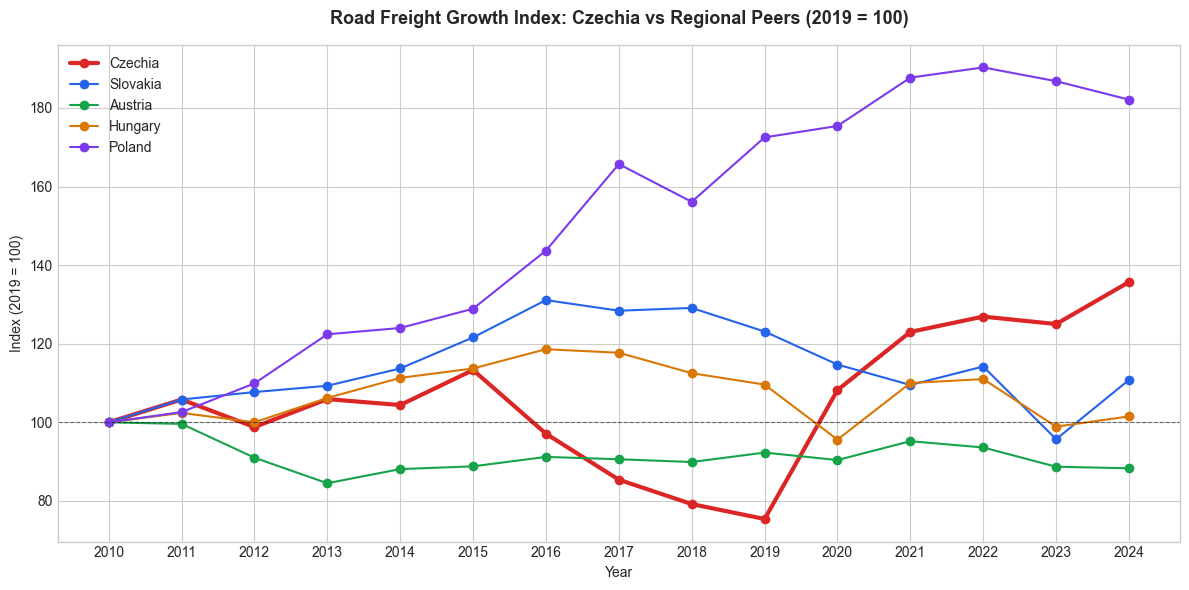

In [17]:
# Czechia vs regional peers
czechia_peers = ['Czechia', 'Slovakia', 'Austria', 'Hungary', 'Poland']

df_czechia = df_countries_full[df_countries_full['country'].isin(czechia_peers)].copy()

# Index to 2019 = 100 for fair comparison
base = df_czechia[df_czechia['year'] == 2010][['country', 'tkm_millions']].rename(
    columns={'tkm_millions': 'base_tkm'})
df_czechia = df_czechia.merge(base, on='country')
df_czechia['indexed'] = (df_czechia['tkm_millions'] / df_czechia['base_tkm'] * 100).round(1)

# Print year by year
pivot_czechia = df_czechia.pivot(index='year', columns='country', values='indexed')
print('Indexed performance (2019 = 100):')
print(pivot_czechia.to_string())

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    'Czechia': '#dc2626',
    'Slovakia': '#2563eb',
    'Austria': '#16a34a',
    'Hungary': '#d97706',
    'Poland': '#7c3aed'
}

for country in czechia_peers:
    data = df_czechia[df_czechia['country'] == country]
    lw = 3 if country == 'Czechia' else 1.5
    ax.plot(data['year'], data['indexed'],
            marker='o', linewidth=lw, label=country,
            color=colors[country])

ax.axhline(y=100, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Road Freight Growth Index: Czechia vs Regional Peers (2019 = 100)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Index (2019 = 100)')
ax.set_xticks(df_czechia['year'].unique())
ax.legend()

plt.tight_layout()
plt.savefig(r'C:\dev\portfolio\project-3-eu-road-tpt\charts\chart6_czechia_peers.png', dpi=150)
plt.show()

In [ ]:
## Summary of Findings

This analysis of EU-27 road freight transport performance across 2015–2024 
reveals four key findings:

### 1. Post-COVID Surge Was the Anomaly, Not the Baseline
Total EU freight grew steadily from 1,614,870M TKM in 2015 to 1,813,524M TKM 
in 2019. COVID caused a modest 0.8% dip in 2020, followed by an exceptional 
demand surge in 2021-2022. The 2023 contraction represents normalisation toward 
the long-run trend rather than structural decline.

### 2. Poland Leads EU Road Freight by a Significant Margin
Poland (368,314M TKM in 2024) exceeds Germany (280,840M TKM) by 31% — a gap 
that has widened consistently since 2019. This reflects structural competitive 
advantages in cost, geography, and fleet scale rather than any single geopolitical 
event.

### 3. A Clear East-West Performance Divide Has Emerged
15 of 28 countries recorded net declines from 2019-2024, predominantly in western 
Europe (Portugal -25.5%, Germany -10.0%). Eastern and central European countries 
are gaining freight share, driven by lower operating costs and supply chain 
restructuring post-COVID.

## Finding 4 (Final): Czechia's Growth Reflects Recovery, Not Anomaly

Initial analysis using 2019 as a baseline flagged Czechia's +80.1% growth as 
a potential reporting anomaly — a near-doubling during a period when peers 
contracted or held flat seemed implausible.

Extending the index to 2010 reveals the correct interpretation.

| Year | Austria | Czechia | Hungary | Poland | Slovakia |
|------|---------|---------|---------|--------|----------|
| 2010 | 100.0 | 100.0 | 100.0 | 100.0 | 100.0 |
| 2015 | 88.8 | 113.3 | 113.7 | 128.9 | 121.6 |
| 2017 | 90.6 | 85.4 | 117.7 | 165.7 | 128.4 |
| 2019 | 92.3 | 75.4 | 109.6 | 172.5 | 123.1 |
| 2022 | 93.6 | 126.9 | 111.0 | 190.3 | 114.2 |
| 2024 | 88.3 | 135.7 | 101.5 | 182.1 | 110.8 |

**What actually happened:**
- Czechia grew broadly in line with peers from 2010 to ~2015
- From 2015 to 2019 Czechia lost significant freight share — declining to 75.4 
  against a 2010 base while Poland reached 172.5
- The 2019 baseline used in the initial growth analysis captured Czechia at 
  a trough, not a representative starting point
- Post-2020 growth to 135.7 reflects genuine recovery of lost share, 
  consistent with regional economic patterns

**Poland remains the standout performer across the full period** — 
growing from 100 to 182.1 over 14 years with no interruption, 
confirming that its dominance is a long-run structural trend, 
not a recent phenomenon.

**Why did Czechia lose share 2015-2019?**
The data does not answer this directly, but plausible explanations include:
- Competitive displacement by lower-cost Polish and Slovak operators
- Structural shifts in Czech manufacturing away from freight-intensive industries
- Currency and cost dynamics making Czech trucking less competitive internationally

This remains an open question for further investigation.

---

### Analytical Note: The Importance of Baseline Selection

This finding illustrates a core principle of data analysis — 
**the choice of baseline materially affects conclusions.**

A 2019-only view produced a misleading outlier. A 2010 view revealed 
a coherent recovery story. Before drawing conclusions from growth rates, 
always ask: *is this baseline representative?*

The initial anomaly flag, the investigation, and the revised conclusion 
are all part of the analytical record — and more valuable collectively 
than a clean result would have been.

---
*Data: Eurostat road_go_ta_tott | Unit: Million Tonne-Kilometres | 
Analysis: Python (pandas, matplotlib)*